<a href="https://www.kaggle.com/code/sonawanelalitsunil/ev-car-performance-and-battery-analysis-eda-97-92?scriptVersionId=270068447" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/electric-car-performance-and-battery-dataset/electric_vehicles_spec_2025.csv.csv


## Title: Electric Car Performance and Battery Dataset

## Description:
This dataset provides detailed insights into the performance metrics and battery characteristics of various electric car models. It includes information such as vehicle specifications, battery capacity, charging time, range, energy efficiency, and power output. The dataset can be used for analyzing relationships between battery size and driving range, comparing car models based on performance, predicting energy consumption, and studying the impact of technology on electric vehicle efficiency. It is valuable for data-driven research, predictive modeling, and sustainability analysis in the electric mobility domain.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/electric-car-performance-and-battery-dataset/electric_vehicles_spec_2025.csv.csv")

In [3]:
df.head()

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,Abarth,500e Convertible,155,37.8,Lithium-ion,192.0,235.0,156,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1904/Abarth-500e-C...
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,192.0,235.0,149,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1903/Abarth-500e-H...
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,102.0,345.0,158,280,5.9,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3057/Abarth-600e-S...
3,Abarth,600e Turismo,200,50.8,Lithium-ion,102.0,345.0,158,280,6.2,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3056/Abarth-600e-T...
4,Aiways,U5,150,60.0,Lithium-ion,NaN,310.0,156,315,7.5,...,NaN,496,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5


In [4]:
df.tail()

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
473,Zeekr,7X Premium RWD,210,71.0,Lithium-ion,NaN,440.0,148,365,6.0,...,2000.0,539,5,RWD,JD - Large,4787,1930,1650,SUV,https://ev-database.org/car/3081/Zeekr-7X-Prem...
474,Zeekr,X Core RWD (MY25),190,49.0,Lithium-ion,NaN,343.0,148,265,5.9,...,1600.0,362,5,RWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3197/Zeekr-X-Core-RWD
475,Zeekr,X Long Range RWD (MY25),190,65.0,Lithium-ion,NaN,343.0,146,360,5.6,...,1600.0,362,5,RWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3198/Zeekr-X-Long-...
476,Zeekr,X Privilege AWD (MY25),190,65.0,Lithium-ion,NaN,543.0,153,350,3.8,...,1600.0,362,5,AWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3199/Zeekr-X-Privi...
477,firefly,NaN,150,41.2,Lithium-ion,112.0,200.0,125,250,8.1,...,0.0,404,5,RWD,B - Compact,4003,1885,1557,Hatchback,https://ev-database.org/car/3178/firefly-firefly


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand                      478 non-null    object 
 1   model                      477 non-null    object 
 2   top_speed_kmh              478 non-null    int64  
 3   battery_capacity_kWh       478 non-null    float64
 4   battery_type               478 non-null    object 
 5   number_of_cells            276 non-null    float64
 6   torque_nm                  471 non-null    float64
 7   efficiency_wh_per_km       478 non-null    int64  
 8   range_km                   478 non-null    int64  
 9   acceleration_0_100_s       478 non-null    float64
 10  fast_charging_power_kw_dc  477 non-null    float64
 11  fast_charge_port           477 non-null    object 
 12  towing_capacity_kg         452 non-null    float64
 13  cargo_volume_l             477 non-null    object 

In [6]:
df.describe()

,top_speed_kmh,battery_capacity_kWh,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,towing_capacity_kg,seats,length_mm,width_mm,height_mm
count,478.000000,478.000000,276.000000,471.000000,478.000000,478.000000,478.000000,477.000000,452.000000,478.000000,478.000000,478.000000,478.000000
mean,185.487448,74.043724,485.293478,498.012739,162.903766,393.179916,6.882636,125.008386,1052.261062,5.263598,4678.506276,1887.359833,1601.125523
std,34.252773,20.331058,1210.819733,241.461128,34.317532,103.287335,2.730696,58.205012,737.851774,1.003961,369.210573,73.656807,130.754851
min,125.000000,21.300000,72.000000,113.000000,109.000000,135.000000,2.200000,29.000000,0.000000,2.000000,3620.000000,1610.000000,1329.000000
25%,160.000000,60.000000,150.000000,305.000000,143.000000,320.000000,4.800000,80.000000,500.000000,5.000000,4440.000000,1849.000000,1514.000000
50%,180.000000,76.150000,216.000000,430.000000,155.000000,397.500000,6.600000,113.000000,1000.000000,5.000000,4720.000000,1890.000000,1596.000000
75%,201.000000,90.600000,324.000000,679.000000,177.750000,470.000000,8.200000,150.000000,1600.000000,5.000000,4961.000000,1939.000000,1665.000000
max,325.000000,118.000000,7920.000000,1350.000000,370.000000,685.000000,19.100000,281.000000,2500.000000,9.000000,5908.000000,2080.000000,1986.000000


In [7]:
df.isnull().sum()

brand                          0
model                          1
top_speed_kmh                  0
battery_capacity_kWh           0
battery_type                   0
number_of_cells              202
torque_nm                      7
efficiency_wh_per_km           0
range_km                       0
acceleration_0_100_s           0
fast_charging_power_kw_dc      1
fast_charge_port               1
towing_capacity_kg            26
cargo_volume_l                 1
seats                          0
drivetrain                     0
segment                        0
length_mm                      0
width_mm                       0
height_mm                      0
car_body_type                  0
source_url                     0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

brand                         object
model                         object
top_speed_kmh                  int64
battery_capacity_kWh         float64
battery_type                  object
number_of_cells              float64
torque_nm                    float64
efficiency_wh_per_km           int64
range_km                       int64
acceleration_0_100_s         float64
fast_charging_power_kw_dc    float64
fast_charge_port              object
towing_capacity_kg           float64
cargo_volume_l                object
seats                          int64
drivetrain                    object
segment                       object
length_mm                      int64
width_mm                       int64
height_mm                      int64
car_body_type                 object
source_url                    object
dtype: object

In [10]:
df.shape

(478, 22)

In [11]:
df.nunique()

brand                         59
model                        477
top_speed_kmh                 38
battery_capacity_kWh         121
battery_type                   1
number_of_cells               38
torque_nm                    128
efficiency_wh_per_km         112
range_km                      88
acceleration_0_100_s          97
fast_charging_power_kw_dc     71
fast_charge_port               2
towing_capacity_kg            26
cargo_volume_l               140
seats                          7
drivetrain                     3
segment                       15
length_mm                    172
width_mm                     108
height_mm                    162
car_body_type                  8
source_url                   478
dtype: int64

In [12]:
df.describe().loc[['mean','max','min']]

,top_speed_kmh,battery_capacity_kWh,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,towing_capacity_kg,seats,length_mm,width_mm,height_mm
mean,185.487448,74.043724,485.293478,498.012739,162.903766,393.179916,6.882636,125.008386,1052.261062,5.263598,4678.506276,1887.359833,1601.125523
max,325.000000,118.000000,7920.000000,1350.000000,370.000000,685.000000,19.100000,281.000000,2500.000000,9.000000,5908.000000,2080.000000,1986.000000
min,125.000000,21.300000,72.000000,113.000000,109.000000,135.000000,2.200000,29.000000,0.000000,2.000000,3620.000000,1610.000000,1329.000000


In [13]:
df.columns

Index(['brand', 'model', 'top_speed_kmh', 'battery_capacity_kWh',
       'battery_type', 'number_of_cells', 'torque_nm', 'efficiency_wh_per_km',
       'range_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc',
       'fast_charge_port', 'towing_capacity_kg', 'cargo_volume_l', 'seats',
       'drivetrain', 'segment', 'length_mm', 'width_mm', 'height_mm',
       'car_body_type', 'source_url'],
      dtype='object')

## Data visualizations

In [14]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

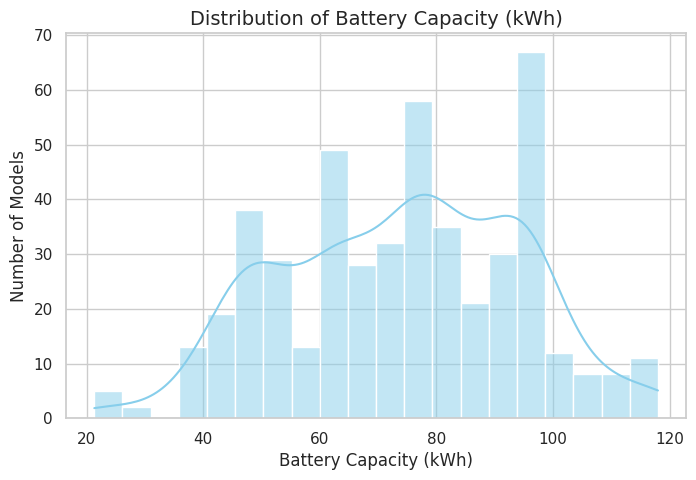

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(df['battery_capacity_kWh'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Battery Capacity (kWh)')
plt.xlabel('Battery Capacity (kWh)')
plt.ylabel('Number of Models')
plt.show()

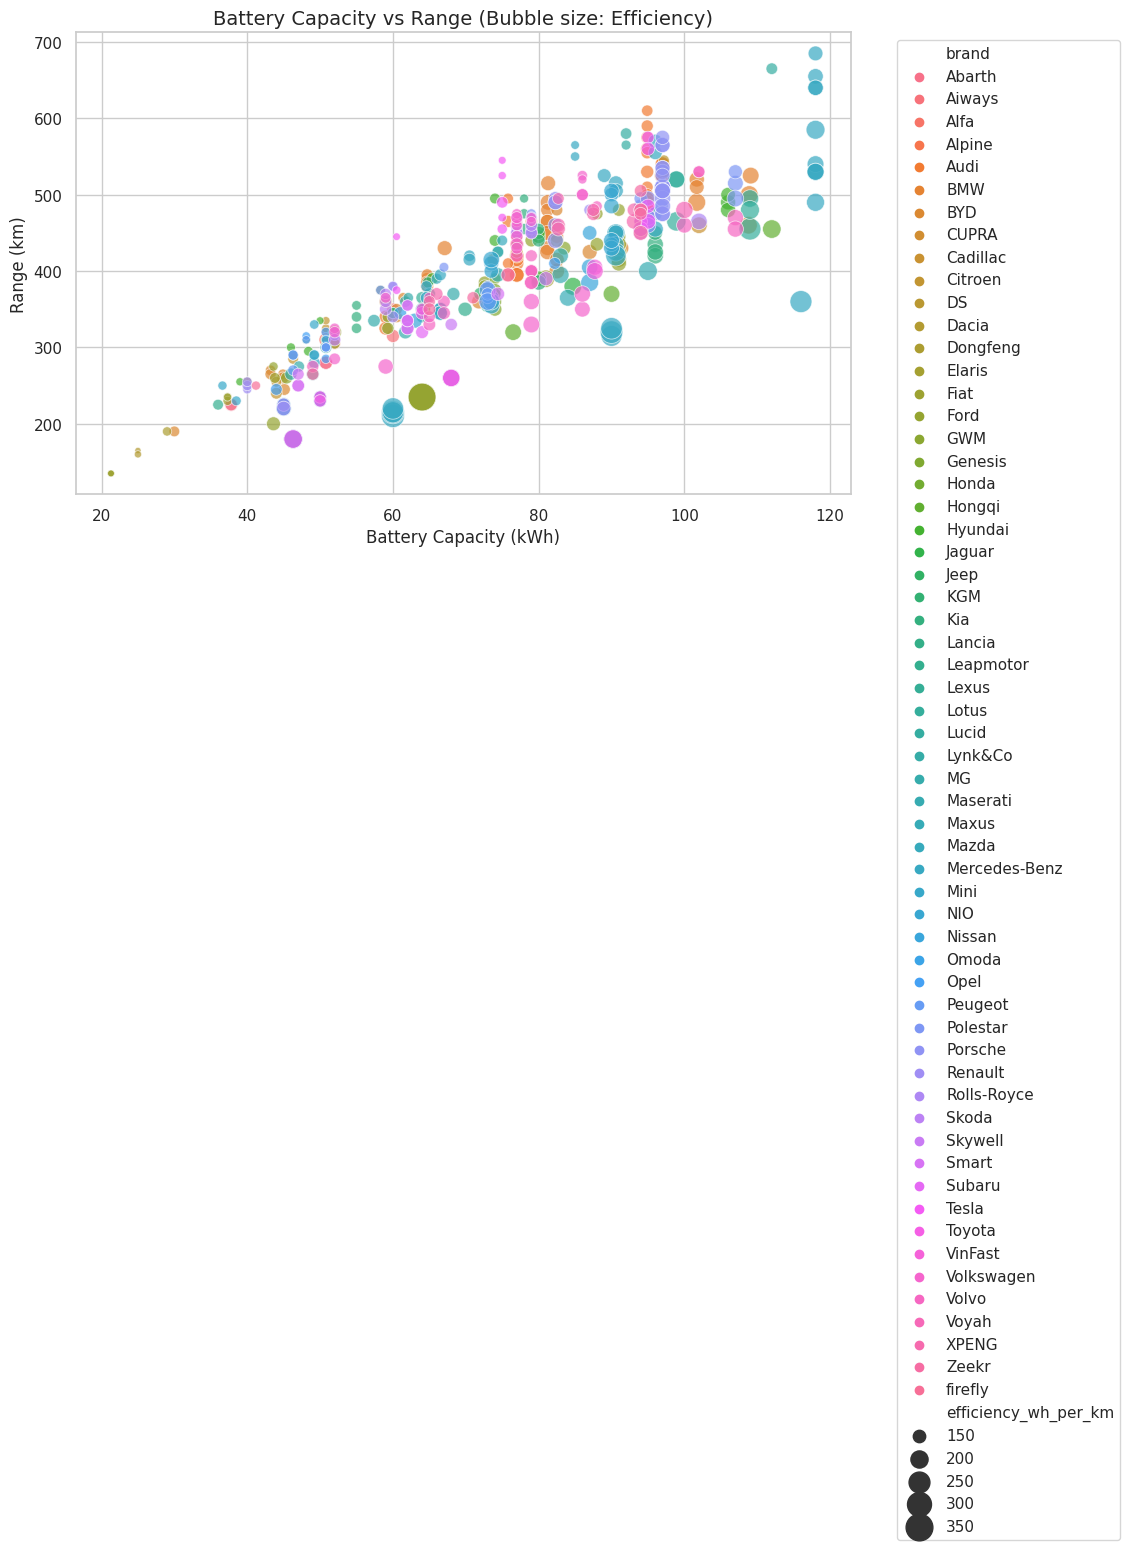

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='battery_capacity_kWh', y='range_km',
                size='efficiency_wh_per_km', hue='brand', alpha=0.7, sizes=(20, 400))
plt.title('Battery Capacity vs Range (Bubble size: Efficiency)')
plt.xlabel('Battery Capacity (kWh)')
plt.ylabel('Range (km)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

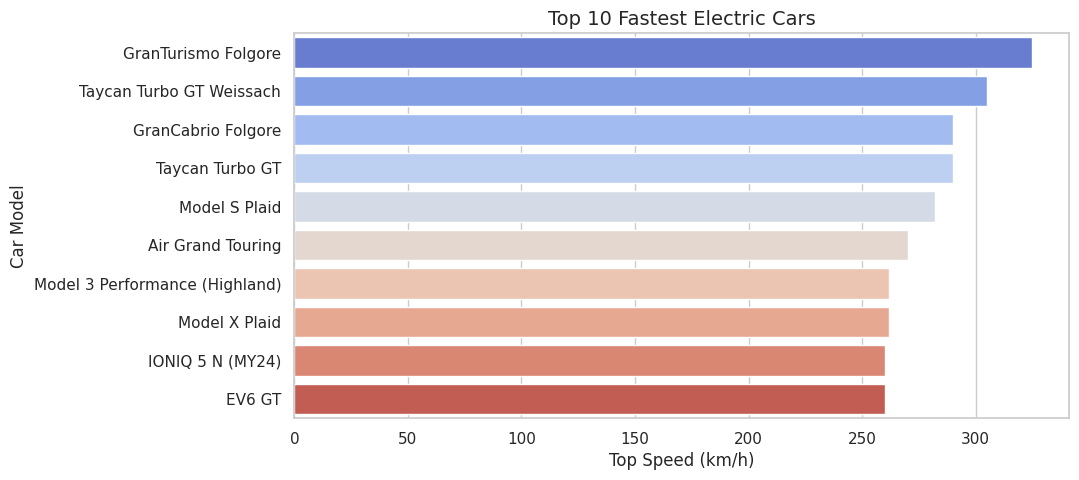

In [17]:
top_speed = df.nlargest(10, 'top_speed_kmh')
sns.barplot(data=top_speed, x='top_speed_kmh', y='model', palette='coolwarm')
plt.title('Top 10 Fastest Electric Cars')
plt.xlabel('Top Speed (km/h)')
plt.ylabel('Car Model')
plt.show()

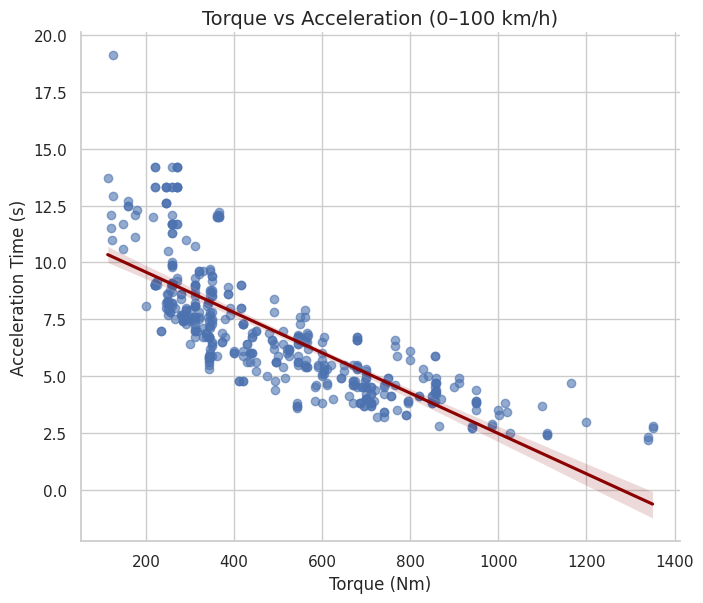

In [18]:
sns.lmplot(data=df, x='torque_nm', y='acceleration_0_100_s',
           height=6, aspect=1.2, scatter_kws={'alpha':0.6}, line_kws={'color':'darkred'})
plt.title('Torque vs Acceleration (0–100 km/h)')
plt.xlabel('Torque (Nm)')
plt.ylabel('Acceleration Time (s)')
plt.show()


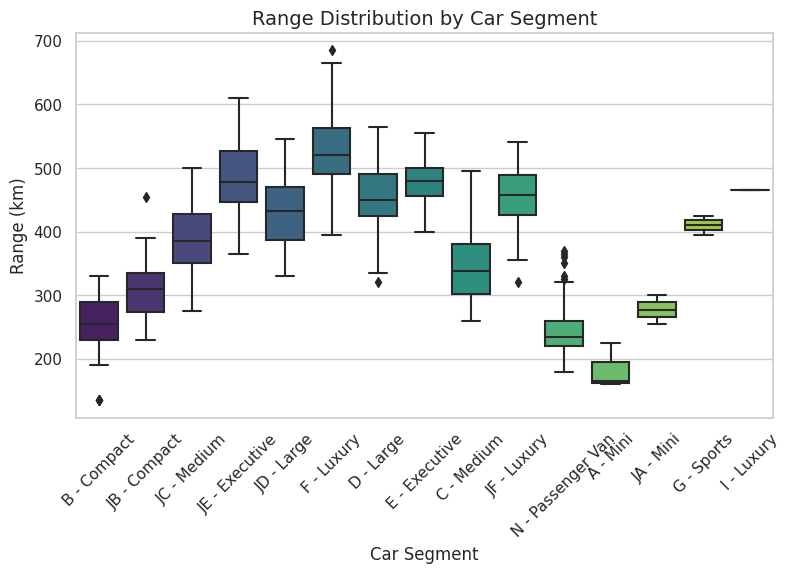

In [19]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='segment', y='range_km', palette='viridis')
plt.title('Range Distribution by Car Segment')
plt.xlabel('Car Segment')
plt.ylabel('Range (km)')
plt.xticks(rotation=45)
plt.show()

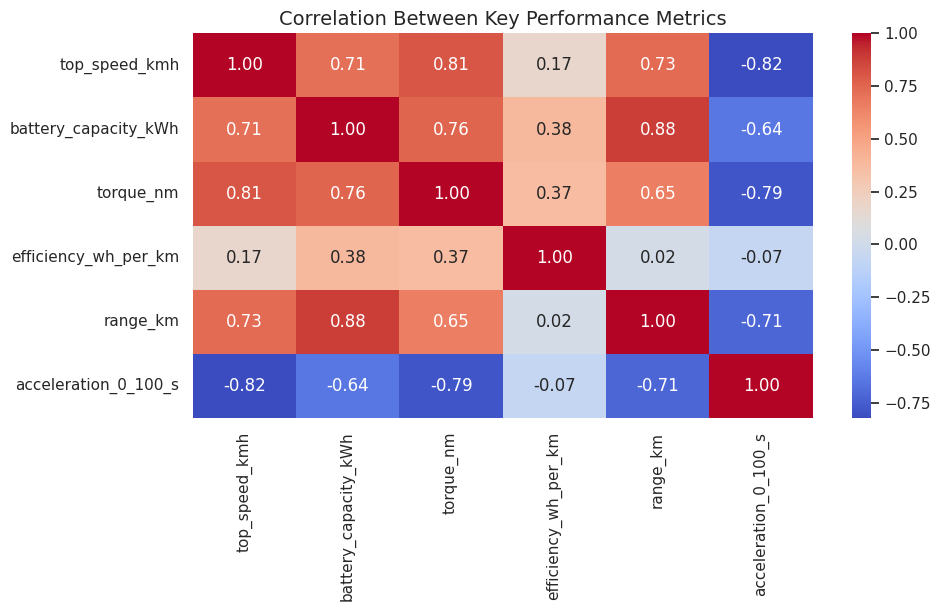

In [20]:
numeric_cols = ['top_speed_kmh', 'battery_capacity_kWh', 'torque_nm', 
                'efficiency_wh_per_km', 'range_km', 'acceleration_0_100_s']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Key Performance Metrics')
plt.show()

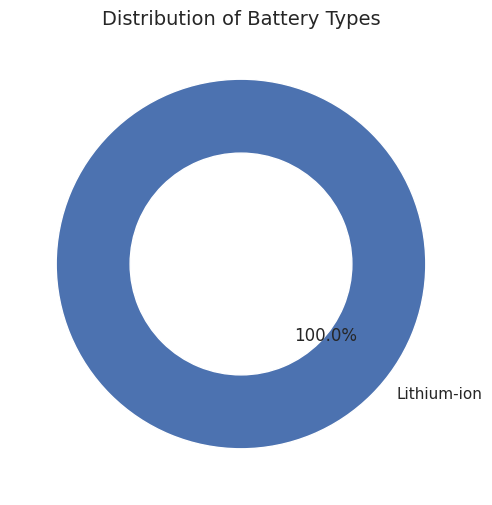

In [21]:
battery_counts = df['battery_type'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(battery_counts, labels=battery_counts.index, autopct='%1.1f%%', startangle=140, 
        wedgeprops={'width': 0.4})
plt.title('Distribution of Battery Types')
plt.show()

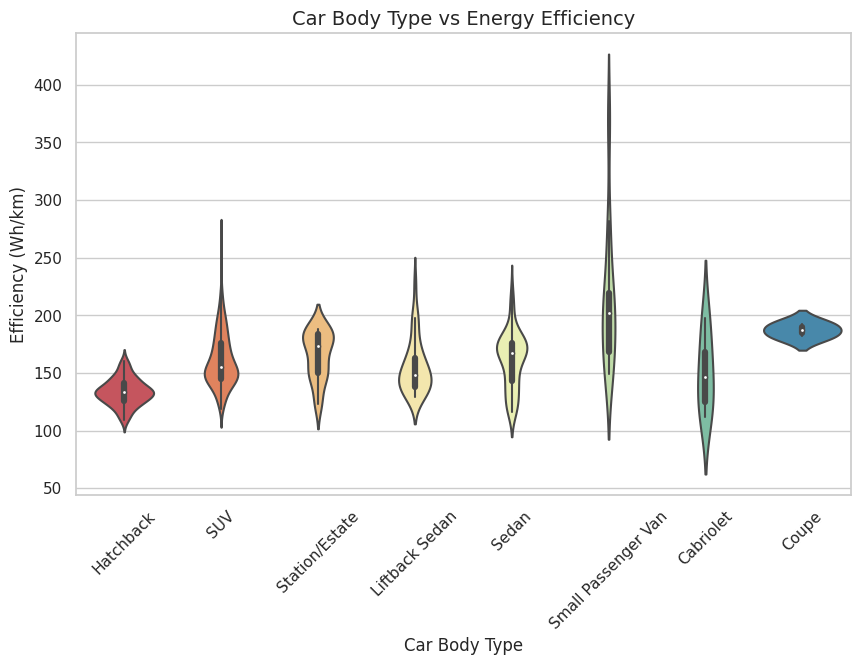

In [22]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='car_body_type', y='efficiency_wh_per_km', palette='Spectral')
plt.title('Car Body Type vs Energy Efficiency')
plt.xlabel('Car Body Type')
plt.ylabel('Efficiency (Wh/km)')
plt.xticks(rotation=45)
plt.show()

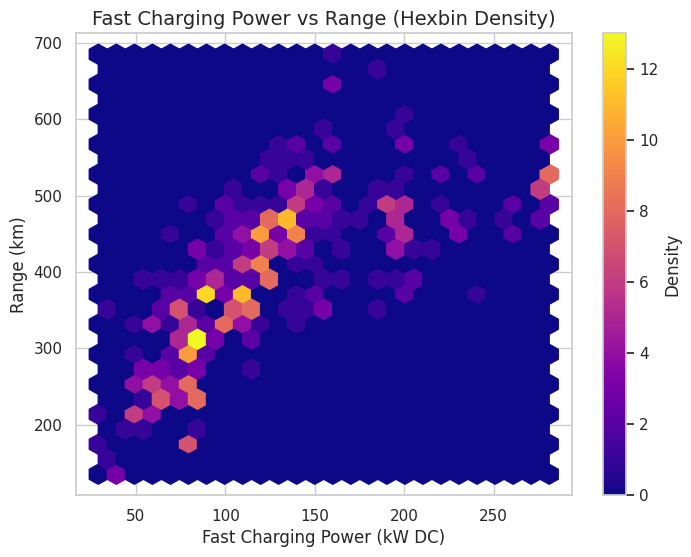

In [23]:
plt.figure(figsize=(8, 6))
plt.hexbin(df['fast_charging_power_kw_dc'], df['range_km'], gridsize=25, cmap='plasma')
plt.colorbar(label='Density')
plt.title('Fast Charging Power vs Range (Hexbin Density)')
plt.xlabel('Fast Charging Power (kW DC)')
plt.ylabel('Range (km)')
plt.show()

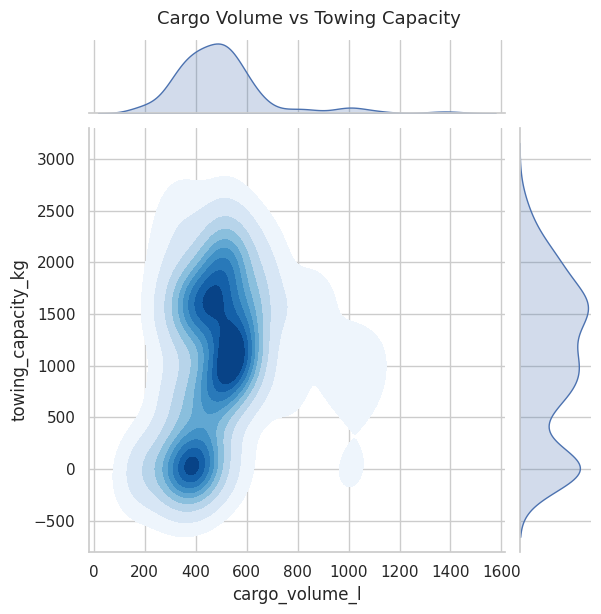

In [24]:
df['cargo_volume_l'] = pd.to_numeric(df['cargo_volume_l'], errors='coerce')
df['towing_capacity_kg'] = pd.to_numeric(df['towing_capacity_kg'], errors='coerce')
df_clean = df.dropna(subset=['cargo_volume_l', 'towing_capacity_kg'])
sns.jointplot(
    data=df_clean,
    x='cargo_volume_l',
    y='towing_capacity_kg',
    kind='kde',
    fill=True,
    cmap='Blues'
)

plt.suptitle('Cargo Volume vs Towing Capacity', y=1.02, fontsize=13)
plt.show()


## Ml Algorithms

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [26]:
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col].fillna(df[col].mean(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

In [27]:
label_enc = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_enc.fit_transform(df[col].astype(str))


In [28]:
X = df.drop('segment', axis=1)
y = df['segment']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

In [30]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = round(acc, 2)
    print(f"{name} Accuracy: {acc:.2f}%")

Logistic Regression Accuracy: 75.00%
Decision Tree Accuracy: 95.83%
Random Forest Accuracy: 95.83%
Gradient Boosting Accuracy: 97.92%
KNN Accuracy: 71.88%
SVM Accuracy: 33.33%


In [31]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])

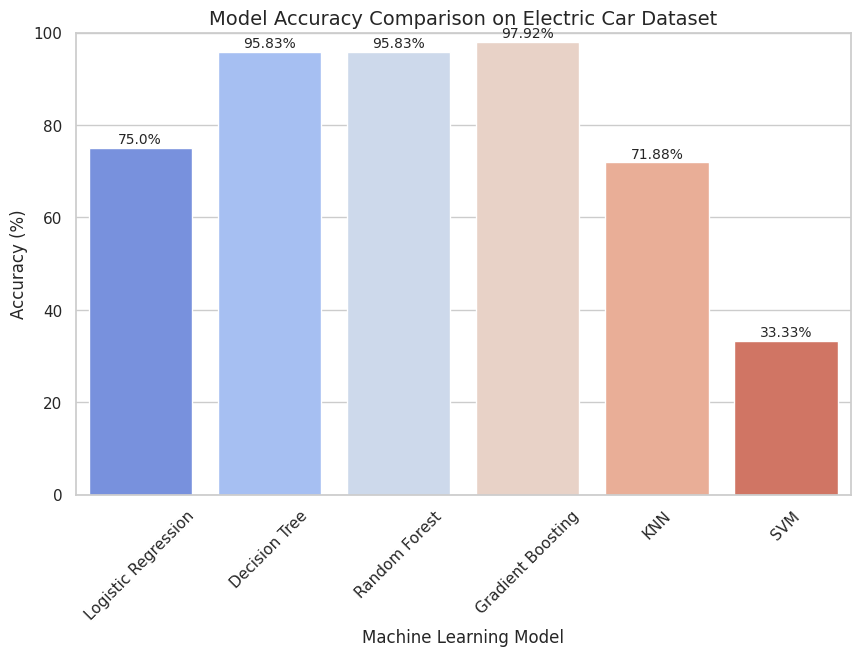

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Model', y='Accuracy', palette='coolwarm')
plt.title('Model Accuracy Comparison on Electric Car Dataset', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.xlabel('Machine Learning Model')
plt.xticks(rotation=45)
plt.ylim(0, 100)
for i, val in enumerate(results_df['Accuracy']):
    plt.text(i, val + 1, f"{val}%", ha='center', fontsize=10)
plt.show()

## THank you...pls upvote!!!!